# 01 Setup And Data Prep

This notebook prepares the paired `maps/` dataset into the Pix2Pix-ready folder layout used by the rest of the project.

If `~/tmp/maps` is missing, it can automatically download the official Berkeley Pix2Pix `maps.tar.gz` archive, extract it, and verify the dataset layout before preprocessing starts.


In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "i2i").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current notebook directory.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

print(f"Repo root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")


Repo root: /home/arderd/gan-lab-task-2
Working directory: /home/arderd/gan-lab-task-2


In [2]:
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path

HOME = Path.home()
TMP_ROOT = HOME / "tmp"
INPUT_ROOT = TMP_ROOT / "maps"
ARCHIVE_PATH = TMP_ROOT / "maps.tar.gz"
DATASET_URL = "https://efrosgans.eecs.berkeley.edu/pix2pix/datasets/maps.tar.gz"
AUTO_DOWNLOAD_IF_MISSING = True
FORCE_REDOWNLOAD = False

OUTPUT_ROOT = TMP_ROOT / "data" / "pix2pix-801010"
IMAGE_SIZE = 256
SPLIT_MODE = "global"
GLOBAL_TRAIN_RATIO = 0.8
GLOBAL_VAL_RATIO = 0.1
VAL_RATIO = 0.5
SEED = 42
IMAGE_FORMAT = "png"
JPEG_QUALITY = 95
LIMIT_TRAIN = None
LIMIT_VAL = None
OVERWRITE = True

{
    "input_root": str(INPUT_ROOT),
    "archive_path": str(ARCHIVE_PATH),
    "dataset_url": DATASET_URL,
    "auto_download_if_missing": AUTO_DOWNLOAD_IF_MISSING,
    "force_redownload": FORCE_REDOWNLOAD,
    "output_root": str(OUTPUT_ROOT),
    "image_size": IMAGE_SIZE,
    "split_mode": SPLIT_MODE,
    "overwrite": OVERWRITE,
}


{'input_root': '/home/arderd/tmp/maps',
 'archive_path': '/home/arderd/tmp/maps.tar.gz',
 'dataset_url': 'https://efrosgans.eecs.berkeley.edu/pix2pix/datasets/maps.tar.gz',
 'auto_download_if_missing': True,
 'force_redownload': False,
 'output_root': '/home/arderd/tmp/data/pix2pix-801010',
 'image_size': 256,
 'split_mode': 'global',
 'overwrite': True}

In [4]:
import tarfile
import shutil
import urllib.request
from pathlib import Path

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
EXPECTED_SPLITS = ("train", "val")

def count_split_images(root: Path) -> dict[str, int]:
    counts = {}
    for split in EXPECTED_SPLITS:
        split_dir = root / split
        if not split_dir.exists():
            counts[split] = 0
            continue
        counts[split] = len([
            path
            for path in split_dir.iterdir()
            if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
        ])
    return counts

def has_valid_maps_layout(root: Path) -> bool:
    counts = count_split_images(root)
    return all(counts[split] > 0 for split in EXPECTED_SPLITS)

def print_maps_status(root: Path) -> dict[str, int]:
    counts = count_split_images(root)
    print(f"Dataset root: {root}")
    for split, count in counts.items():
        print(f"  {split}: {count} files")
    return counts

def download_file(url: str, destination: Path, chunk_size: int = 1024 * 1024) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url) as response, destination.open("wb") as output_file:
        total = response.headers.get("Content-Length")
        total_bytes = int(total) if total is not None else None
        downloaded = 0
        next_report = 25 * 1024 * 1024

        while True:
            chunk = response.read(chunk_size)
            if not chunk:
                break
            output_file.write(chunk)
            downloaded += len(chunk)

            if downloaded >= next_report or (total_bytes is not None and downloaded == total_bytes):
                if total_bytes:
                    print(f"Downloaded {downloaded / (1024 * 1024):.1f} MB / {total_bytes / (1024 * 1024):.1f} MB")
                else:
                    print(f"Downloaded {downloaded / (1024 * 1024):.1f} MB")
                next_report += 25 * 1024 * 1024

def safe_extract_tar(archive_path: Path, destination: Path) -> None:
    with tarfile.open(archive_path, "r:gz") as archive:
        members = archive.getmembers()
        destination_resolved = destination.resolve()
        for member in members:
            member_path = (destination / member.name).resolve()
            if not str(member_path).startswith(str(destination_resolved)):
                raise RuntimeError(f"Unsafe archive member path detected: {member.name}")
        archive.extractall(destination)

def ensure_maps_dataset(
    *,
    input_root: Path,
    archive_path: Path,
    dataset_url: str,
    auto_download_if_missing: bool,
    force_redownload: bool,
) -> dict[str, int]:
    input_root.parent.mkdir(parents=True, exist_ok=True)

    dataset_ready = has_valid_maps_layout(input_root)
    if dataset_ready and not force_redownload:
        print("Using existing dataset already present on disk.")
        return print_maps_status(input_root)

    if not auto_download_if_missing and not dataset_ready:
        raise RuntimeError(
            f"Dataset not found at {input_root}. Set AUTO_DOWNLOAD_IF_MISSING=True or place the dataset there manually."
        )

    if force_redownload or not archive_path.exists():
        print(f"Downloading dataset from {dataset_url}")
        download_file(dataset_url, archive_path)
    else:
        print(f"Using existing archive: {archive_path}")

    if input_root.exists():
        shutil.rmtree(input_root)

    print(f"Extracting archive into {input_root.parent}")
    safe_extract_tar(archive_path, input_root.parent)

    if not has_valid_maps_layout(input_root):
        raise RuntimeError(
            f"Dataset extraction completed but the expected maps/train and maps/val layout was not found under {input_root}."
        )

    print("Dataset download and extraction check passed.")
    return print_maps_status(input_root)

dataset_counts = ensure_maps_dataset(
    input_root=INPUT_ROOT,
    archive_path=ARCHIVE_PATH,
    dataset_url=DATASET_URL,
    auto_download_if_missing=AUTO_DOWNLOAD_IF_MISSING,
    force_redownload=FORCE_REDOWNLOAD,
)

dataset_counts


Using existing dataset already present on disk.
Dataset root: /home/arderd/tmp/maps
  train: 1096 files
  val: 1098 files


{'train': 1096, 'val': 1098}

In [5]:
import csv
import random
import shutil
from dataclasses import dataclass

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
RESAMPLE = Image.Resampling.LANCZOS if hasattr(Image, "Resampling") else Image.LANCZOS

@dataclass(frozen=True)
class PairJob:
    split: str
    source_path: Path
    output_stem: str

def image_sort_key(path: Path) -> tuple[int, int | str]:
    stem = path.stem
    if stem.isdigit():
        return (0, int(stem))
    return (1, stem.lower())

def list_images(directory: Path) -> list[Path]:
    if not directory.exists():
        raise FileNotFoundError(f"Directory not found: {directory}")
    files = [
        path
        for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS
    ]
    return sorted(files, key=image_sort_key)

def unique_stems(paths: list[Path]) -> list[str]:
    seen: dict[str, int] = {}
    stems: list[str] = []
    for path in paths:
        base = path.stem
        index = seen.get(base, 0)
        seen[base] = index + 1
        stems.append(base if index == 0 else f"{base}_{index}")
    return stems

def build_jobs(
    train_paths: list[Path],
    val_paths: list[Path],
    *,
    split_mode: str,
    val_ratio: float,
    global_train_ratio: float,
    global_val_ratio: float,
    seed: int,
) -> tuple[list[PairJob], dict[str, int]]:
    rng = random.Random(seed)

    if split_mode == "respect-source":
        train_subset = train_paths
        shuffled_val = val_paths.copy()
        rng.shuffle(shuffled_val)
        val_count = int(round(len(shuffled_val) * val_ratio))
        val_count = max(0, min(val_count, len(shuffled_val)))
        val_subset = shuffled_val[:val_count]
        test_subset = shuffled_val[val_count:]
    else:
        all_paths = train_paths + val_paths
        shuffled_all = all_paths.copy()
        rng.shuffle(shuffled_all)
        train_count = int(round(len(shuffled_all) * global_train_ratio))
        train_count = max(0, min(train_count, len(shuffled_all)))
        max_val_count = len(shuffled_all) - train_count
        val_count = int(round(len(shuffled_all) * global_val_ratio))
        val_count = max(0, min(val_count, max_val_count))
        train_subset = shuffled_all[:train_count]
        val_subset = shuffled_all[train_count : train_count + val_count]
        test_subset = shuffled_all[train_count + val_count :]

    jobs: list[PairJob] = []
    split_sizes = {
        "train": len(train_subset),
        "val": len(val_subset),
        "test": len(test_subset),
    }

    for split, paths in (("train", train_subset), ("val", val_subset), ("test", test_subset)):
        for source_path, stem in zip(paths, unique_stems(paths)):
            jobs.append(PairJob(split=split, source_path=source_path, output_stem=stem))

    return jobs, split_sizes

def prepare_output_dirs(output_root: Path, overwrite: bool) -> None:
    if output_root.exists():
        if not overwrite:
            raise RuntimeError(
                f"Output path exists: {output_root}. Set OVERWRITE=True if you want to rebuild it."
            )
        shutil.rmtree(output_root)
    for split in ("train", "val", "test"):
        (output_root / split / "sat").mkdir(parents=True, exist_ok=True)
        (output_root / split / "map").mkdir(parents=True, exist_ok=True)

def split_and_resize(source_path: Path, size: int) -> tuple[Image.Image, Image.Image]:
    with Image.open(source_path) as image:
        rgb = image.convert("RGB")
        width, height = rgb.size
        if width % 2 != 0:
            raise ValueError(f"Image width must be even for left/right split: {source_path}")
        if width == 0 or height == 0:
            raise ValueError(f"Image has invalid shape: {source_path}")
        half_width = width // 2
        sat = rgb.crop((0, 0, half_width, height)).resize((size, size), RESAMPLE)
        map_img = rgb.crop((half_width, 0, width, height)).resize((size, size), RESAMPLE)
        return sat, map_img

def save_image(image: Image.Image, path: Path, image_format: str, jpeg_quality: int) -> None:
    if image_format == "jpg":
        image.save(path, format="JPEG", quality=jpeg_quality)
    else:
        image.save(path, format="PNG")

def prepare_pix2pix_dataset(
    *,
    input_root: Path,
    output_root: Path,
    image_size: int,
    split_mode: str,
    global_train_ratio: float,
    global_val_ratio: float,
    val_ratio: float,
    seed: int,
    image_format: str,
    jpeg_quality: int,
    overwrite: bool,
    limit_train: int | None = None,
    limit_val: int | None = None,
) -> dict:
    train_paths = list_images(input_root / "train")
    val_paths = list_images(input_root / "val")

    if limit_train is not None:
        train_paths = train_paths[:limit_train]
    if limit_val is not None:
        val_paths = val_paths[:limit_val]

    if not train_paths:
        raise RuntimeError(f"No images found in {input_root / 'train'}")
    if not val_paths:
        raise RuntimeError(f"No images found in {input_root / 'val'}")

    jobs, split_sizes = build_jobs(
        train_paths,
        val_paths,
        split_mode=split_mode,
        val_ratio=val_ratio,
        global_train_ratio=global_train_ratio,
        global_val_ratio=global_val_ratio,
        seed=seed,
    )

    prepare_output_dirs(output_root, overwrite)
    ext = ".jpg" if image_format == "jpg" else ".png"
    manifest_rows: list[tuple[str, str, str, str]] = []

    total = len(jobs)
    for index, job in enumerate(jobs, start=1):
        sat, map_img = split_and_resize(job.source_path, image_size)
        sat_path = output_root / job.split / "sat" / f"{job.output_stem}{ext}"
        map_path = output_root / job.split / "map" / f"{job.output_stem}{ext}"
        save_image(sat, sat_path, image_format, jpeg_quality)
        save_image(map_img, map_path, image_format, jpeg_quality)
        manifest_rows.append(
            (
                job.split,
                str(sat_path.relative_to(output_root)),
                str(map_path.relative_to(output_root)),
                str(job.source_path),
            )
        )
        if index % 250 == 0 or index == total:
            print(f"Processed {index}/{total} images")

    manifest_path = output_root / "manifest.csv"
    with manifest_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["split", "sat_path", "map_path", "source_path"])
        writer.writerows(manifest_rows)

    print("\nDone.")
    print(f"Output directory: {output_root}")
    print(f"Train pairs: {split_sizes['train']}")
    print(f"Val pairs:   {split_sizes['val']}")
    print(f"Test pairs:  {split_sizes['test']}")
    print(f"Manifest:    {manifest_path}")
    print("\nNormalization for training:")
    print("  x_norm = (x / 127.5) - 1.0")

    return {
        "output_root": output_root,
        "manifest_path": manifest_path,
        "split_sizes": split_sizes,
        "manifest_rows": manifest_rows,
    }

def preview_split_samples(output_root: Path, split: str, limit: int = 3) -> None:
    sat_paths = sorted((output_root / split / "sat").glob("*"))[:limit]
    map_paths = sorted((output_root / split / "map").glob("*"))[:limit]
    if not sat_paths or not map_paths:
        print(f"No files available for split={split}")
        return

    cols = min(limit, len(sat_paths), len(map_paths))
    fig, axes = plt.subplots(2, cols, figsize=(4 * cols, 6))
    if cols == 1:
        axes = [[axes[0]], [axes[1]]]
    for idx in range(cols):
        with Image.open(sat_paths[idx]) as sat_image:
            axes[0][idx].imshow(sat_image)
        axes[0][idx].set_title(f"{split} sat")
        axes[0][idx].axis("off")

        with Image.open(map_paths[idx]) as map_image:
            axes[1][idx].imshow(map_image)
        axes[1][idx].set_title(f"{split} map")
        axes[1][idx].axis("off")

    plt.tight_layout()
    plt.show()


In [6]:
prep_result = prepare_pix2pix_dataset(
    input_root=INPUT_ROOT,
    output_root=OUTPUT_ROOT,
    image_size=IMAGE_SIZE,
    split_mode=SPLIT_MODE,
    global_train_ratio=GLOBAL_TRAIN_RATIO,
    global_val_ratio=GLOBAL_VAL_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
    image_format=IMAGE_FORMAT,
    jpeg_quality=JPEG_QUALITY,
    overwrite=OVERWRITE,
    limit_train=LIMIT_TRAIN,
    limit_val=LIMIT_VAL,
)
prep_result["split_sizes"]


Processed 250/2194 images
Processed 500/2194 images
Processed 750/2194 images
Processed 1000/2194 images
Processed 1250/2194 images
Processed 1500/2194 images
Processed 1750/2194 images
Processed 2000/2194 images
Processed 2194/2194 images

Done.
Output directory: /home/arderd/tmp/data/pix2pix-801010
Train pairs: 1755
Val pairs:   219
Test pairs:  220
Manifest:    /home/arderd/tmp/data/pix2pix-801010/manifest.csv

Normalization for training:
  x_norm = (x / 127.5) - 1.0


{'train': 1755, 'val': 219, 'test': 220}

In [7]:
with prep_result["manifest_path"].open("r", encoding="utf-8") as manifest_file:
    reader = csv.DictReader(manifest_file)
    manifest_preview = [row for _, row in zip(range(8), reader)]

display(manifest_preview)


[{'split': 'train',
  'sat_path': 'train/sat/920.png',
  'map_path': 'train/map/920.png',
  'source_path': '/home/arderd/tmp/maps/train/920.jpg'},
 {'split': 'train',
  'sat_path': 'train/sat/24.png',
  'map_path': 'train/map/24.png',
  'source_path': '/home/arderd/tmp/maps/train/24.jpg'},
 {'split': 'train',
  'sat_path': 'train/sat/21.png',
  'map_path': 'train/map/21.png',
  'source_path': '/home/arderd/tmp/maps/val/21.jpg'},
 {'split': 'train',
  'sat_path': 'train/sat/33.png',
  'map_path': 'train/map/33.png',
  'source_path': '/home/arderd/tmp/maps/train/33.jpg'},
 {'split': 'train',
  'sat_path': 'train/sat/1055.png',
  'map_path': 'train/map/1055.png',
  'source_path': '/home/arderd/tmp/maps/train/1055.jpg'},
 {'split': 'train',
  'sat_path': 'train/sat/519.png',
  'map_path': 'train/map/519.png',
  'source_path': '/home/arderd/tmp/maps/train/519.jpg'},
 {'split': 'train',
  'sat_path': 'train/sat/316.png',
  'map_path': 'train/map/316.png',
  'source_path': '/home/arderd/tmp/m

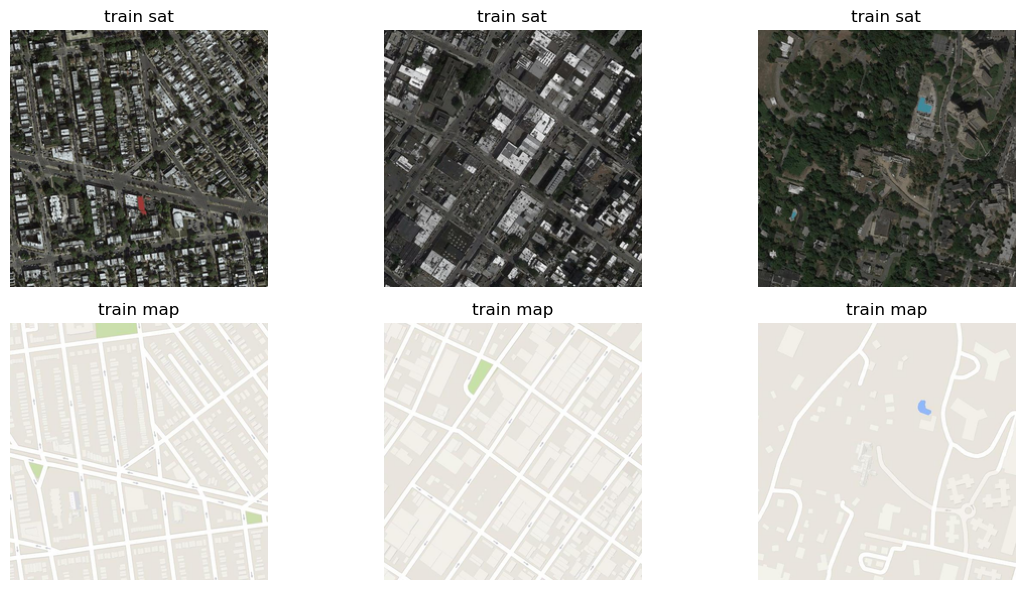

In [ ]:
for split_name in ("train", "val", "test"):
    preview_split_samples(OUTPUT_ROOT, split_name, limit=3)
